# 05 - Defining churn, building and evaluating the model
**Question:** which currently-active customers are likely to stop buying, and how well can we really tell?

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from src.config import *
from src import eda, evaluation as ev
from src.feature_engineering import *
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

In [2]:
customers = pd.read_csv(DATA_PROC / "customers_clean.csv", parse_dates=["customer_registration_date"])
tx = pd.read_csv(DATA_PROC / "transactions_clean.csv.gz", parse_dates=["date"])
orders = build_orders(tx); lines, returns = tx[~tx.is_return], tx[tx.is_return]
M = json.load(open(DATA_PROC / "metrics.json")); H = M["H"]
meta = json.load(open(DATA_PROC / "run_metadata.json"))
START, END = pd.Timestamp(M["data_start"]), pd.Timestamp(M["data_end"])
FEATURES_USED = meta["features_used"]
train_c = [pd.Timestamp(c) for c in M["train_cutoffs"]]; val_c = pd.Timestamp(M["val_cutoff"]); test_c = pd.Timestamp(M["test_cutoff"])
display(Markdown(f"> **Dataset: {meta['name']}** ({'SIMULATED' if meta['kind'] == 'synthetic' else 'real'}) | {M['data_start']} -> {M['data_end']} | churn window **{H} days** ({M['churn_window_source']}). "
                 "All numbers in the commentary below are computed from this dataset when the notebook runs."))

> **Dataset: synthetic_demo** (SIMULATED) | 2024-01-01 -> 2025-12-31 | churn window **90 days** (P95 of purchase gaps = 87 days, rounded up to a multiple of 15). All numbers in the commentary below are computed from this dataset when the notebook runs.

## 1. Churn definition - derived from the data, not assumed

{0.5: 15.0, 0.75: 33.0, 0.9: 62.0, 0.95: 87.0, 0.99: 156.0}
derived H = 90 | used in the pipeline: 90 (P95 of purchase gaps = 87 days, rounded up to a multiple of 15)


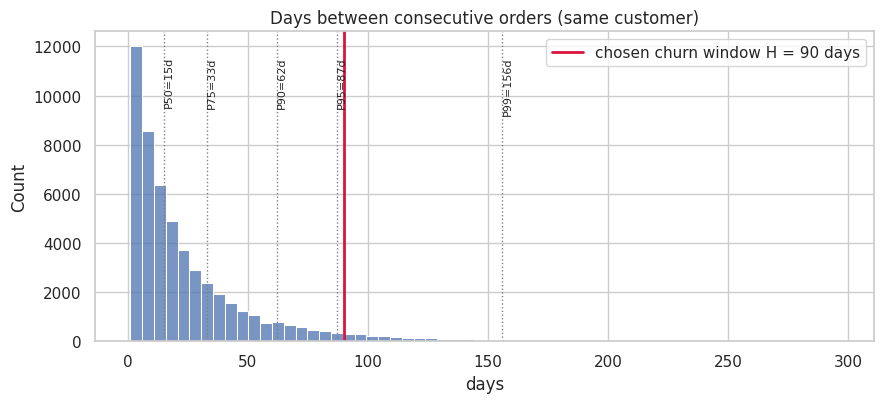

,H_days,eligible_customers,churn_rate
0,30,1755,0.442
1,60,2556,0.314
2,90,3023,0.273
3,120,3293,0.270
4,150,3516,0.279
5,180,3740,0.301


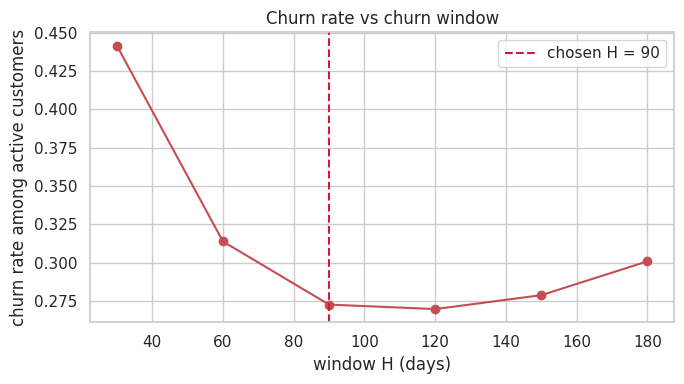

In [3]:
gaps = interpurchase_gaps(orders); H_, qs = choose_churn_window(gaps)
print(qs.round(0).to_dict()); print("derived H =", H_, "| used in the pipeline:", H, f"({M['churn_window_source']})")
eda.fig_gap_distribution(gaps, H, qs); plt.show()
sens = pd.read_csv(DATA_PROC / "churn_window_sensitivity.csv"); display(sens.round(3)); eda.fig_window_sensitivity(sens, H); plt.show()

In [4]:
display(Markdown(f"""**Reasoning.** We want a window long enough that a *normally active* customer rarely stays silent for that long. For this dataset the 95th percentile of observed gaps is **{qs.loc[0.95]:.0f} days**, rounded up to a multiple of 15 and kept inside the safety range: **H = {H} days**. This is *recalculated for every dataset*: it is not a constant of the project.
The sensitivity table shows the churn rate for neighbouring windows: a stable region around H means the label is not an artefact of one arbitrary number; steep changes mean the definition is sensitive (the validation report warns about this).
One limitation: gaps are only observable for customers who did come back, so the true gap distribution is somewhat longer than measured (right-censoring)."""))

**Reasoning.** We want a window long enough that a *normally active* customer rarely stays silent for that long. For this dataset the 95th percentile of observed gaps is **87 days**, rounded up to a multiple of 15 and kept inside the safety range: **H = 90 days**. This is *recalculated for every dataset*: it is not a constant of the project.
The sensitivity table shows the churn rate for neighbouring windows: a stable region around H means the label is not an artefact of one arbitrary number; steep changes mean the definition is sensitive (the validation report warns about this).
One limitation: gaps are only observable for customers who did come back, so the true gap distribution is somewhat longer than measured (right-censoring).

## 2. Observation vs prediction period (no leakage)
```
 features: everything up to cut-off T  |  label: any purchase in (T, T+H] ?
```
Eligible customers are those still active at T (last order <= H days before T). Customers silent for more than H days are already churned by definition, so scoring them would be pointless.

In [5]:
train = make_snapshots(orders, lines, returns, customers, train_c, H, data_end=END)
val = build_snapshot(orders, lines, returns, customers, val_c, H, data_end=END).reset_index()
test = build_snapshot(orders, lines, returns, customers, test_c, H, data_end=END).reset_index()
tbl = pd.DataFrame({"split": ["train", "validation", "test"], "cut-off": [f"{train_c[0].date()} ... {train_c[-1].date()} ({len(train_c)} snapshots)", val_c.date(), test_c.date()],
                    "rows": [len(train), len(val), len(test)], "churn rate": [train.churned.mean(), val.churned.mean(), test.churned.mean()]})
display(tbl.round(3))

,split,cut-off,rows,churn rate
0,train,2024-04-30 ... 2025-03-26 (12 snapshots),26190,0.254
1,validation,2025-07-04,3023,0.273
2,test,2025-10-02,2910,0.201


**Why a time-based split?** Random splitting would put the same customer's future behaviour into training and its past into the test set, and would let the model learn from time periods it is supposed to predict. Here training labels are fully resolved before validation starts, and validation labels before test starts: the test set is a genuine *future*.

The cut-offs above come from the dataset's own first/last dates. If the churn rate differs noticeably between train, validation and test, that is *dataset shift* (e.g. seasonality) and shows up later in the calibration plot.

## 3. Models and metrics

In [6]:
comp = pd.read_csv(DATA_PROC / "model_comparison.csv")
display(comp[["model","val_pr_auc","roc_auc","pr_auc","brier","precision","recall","f1","accuracy"]].round(3))

,model,val_pr_auc,roc_auc,pr_auc,brier,precision,recall,f1,accuracy
0,Logistic (recency only),0.443,0.709,0.380,0.147,0.333,0.649,0.440,0.669
1,Logistic (all features),0.483,0.760,0.413,0.141,0.347,0.726,0.470,0.671
2,Gradient boosting,0.492,0.758,0.421,0.141,0.355,0.723,0.476,0.681
3,Flag everyone as churn (naive),NaN,0.500,0.201,NaN,0.201,1.000,0.334,0.201


Three meaningful approaches only: (1) logistic regression on **recency alone** - what a simple "silent customers" rule would capture; (2) logistic regression on all features - interpretable; (3) gradient boosting - can capture interactions/non-linearity. The model is **selected on the validation metric configured for the run** (see the banner / `selection_metric`) and the test set is only reported afterwards.

How to read the metrics for retention:
* **Accuracy** is misleading (predicting the majority class for everyone already scores 1 - base rate).
* **PR-AUC** (compare with the base rate = what a random ranking gets) measures how well high scores concentrate real churners.
* **Recall** = share of real churners we reach; **precision** = share of contacted customers who were really about to leave. High recall with low precision means contacting many customers who would have stayed.
* **Brier score** checks that probabilities are usable as probabilities.

{'roc_auc': 0.759, 'pr_auc': 0.421, 'brier': 0.141, 'precision': 0.355, 'recall': 0.723, 'f1': 0.476} | base rate 0.201


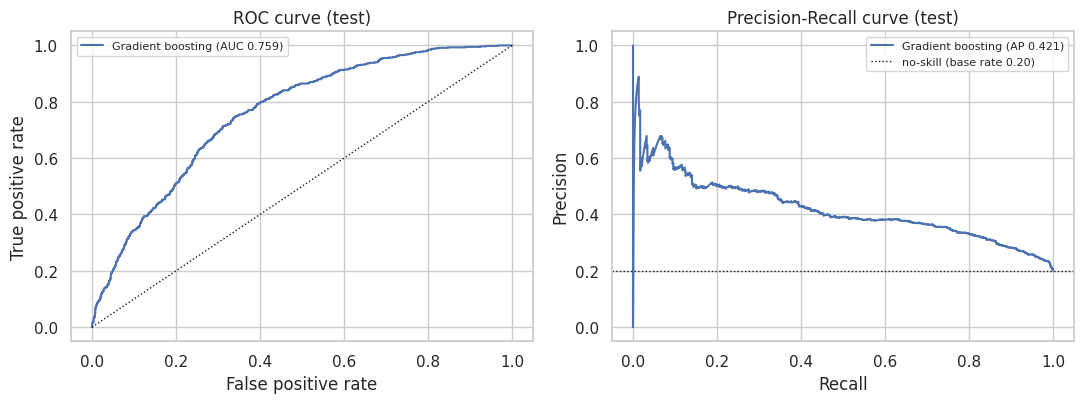

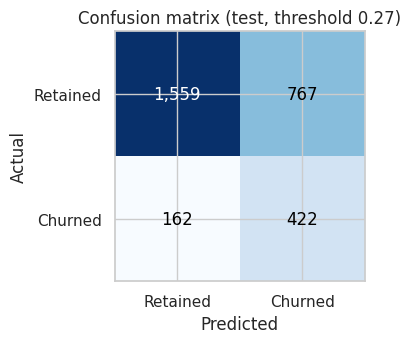

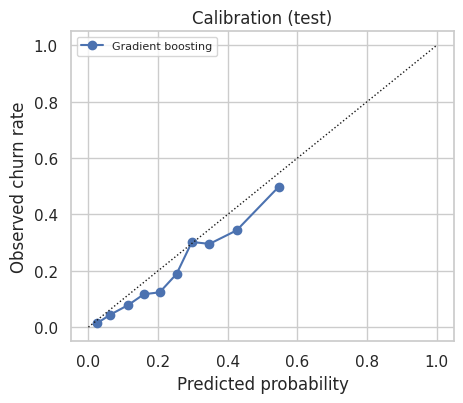

In [7]:
from src.churn_model import load
model = load("churn_model.joblib"); cfg = json.load(open(DATA_PROC / "model_config.json")); feats = cfg["features"]
p = model.predict_proba(test[feats])[:, 1]; y = test.churned.values
thr = M["t_f1"]; m = ev.classification_metrics(y, p, thr)
print({k: round(v, 3) for k, v in m.items() if k in ["roc_auc", "pr_auc", "brier", "precision", "recall", "f1"]}, "| base rate", round(y.mean(), 3))
fig = ev.plot_roc_pr(y, {M["best_model"]: p}); plt.show()
ev.plot_confusion(m, f"Confusion matrix (test, threshold {thr:.2f})"); plt.show()
ev.plot_calibration(y, {M["best_model"]: p}); plt.show()

## 4. From probability to risk tiers
Tiers are set on **validation** outcomes (not on fixed 30/70 cut-offs). The rule used for this run:

> {RULE}

The 2x-base-rate criterion is computed from this dataset's own base churn rate. Tiers are then checked on the untouched test set.

**Rule used for this run:** High = churn probability >= 0.44: on validation data, customers at or above it churned at >= 2x the validation base rate (27.3%). Low = probability <= 0.28: validation churn rate <= 15%. Medium = in between.

,customers,observed_churn_rate,mean_predicted_prob,churners,share_of_customers,share_of_all_churners
risk,,,,,,
Low,1805,0.099,0.141,179,0.620,0.307
Medium,704,0.304,0.348,214,0.242,0.366
High,401,0.476,0.522,191,0.138,0.327


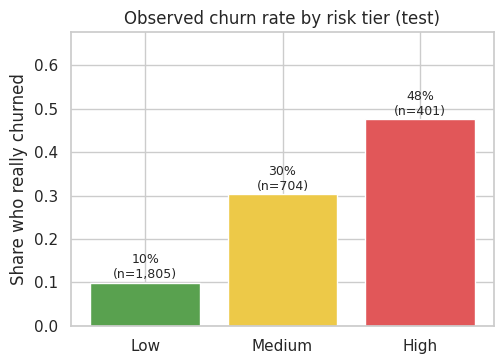

decile,1,2,3,4,5,6,7,8,9,10
customers,291.000,291.000,291.000,291.000,291.000,291.000,291.000,291.000,291.000,291.000
churn_rate,0.498,0.344,0.296,0.302,0.189,0.124,0.117,0.079,0.045,0.014
lift,2.483,1.712,1.473,1.507,0.942,0.616,0.582,0.394,0.223,0.068


In [8]:
t_low, t_high = M["t_low"], M["t_high"]
display(Markdown("**Rule used for this run:** " + meta["risk_rule"]))
tiers = ev.risk_table(y, p, t_low, t_high); display(tiers.round(3))
ev.plot_risk_tiers(tiers); plt.show()
display(ev.decile_lift(y, p).round(3).T)

In [9]:
lo, hi = tiers.loc["Low"], tiers.loc["High"]
display(Markdown(f"""**So what?**
* Observed churn in the test period: **{hi.observed_churn_rate:.0%}** of High-tier customers vs **{lo.observed_churn_rate:.0%}** of Low-tier ones (overall {y.mean():.0%}). The top decile of scores churns at ~{ev.decile_lift(y,p).lift.iloc[0]:.1f}x the base rate.
* It is **not** a crystal ball: test ROC-AUC {m['roc_auc']:.2f}, PR-AUC {m['pr_auc']:.2f} (a random ranking gets {y.mean():.2f}). Part of churn is not predictable from purchase history alone.
* Compare the models in the table above: if 'Logistic (recency only)' is close to the others, a simple "silent for N days" rule captures most of the signal and is the benchmark the model must beat."""))

**So what?**
* Observed churn in the test period: **48%** of High-tier customers vs **10%** of Low-tier ones (overall 20%). The top decile of scores churns at ~2.5x the base rate.
* It is **not** a crystal ball: test ROC-AUC 0.76, PR-AUC 0.42 (a random ranking gets 0.20). Part of churn is not predictable from purchase history alone.
* Compare the models in the table above: if 'Logistic (recency only)' is close to the others, a simple "silent for N days" rule captures most of the signal and is the benchmark the model must beat.

## 5. Threshold and business trade-off
The F1-optimal threshold is a statistical convention. The right threshold depends on what an intervention costs and what a saved customer is worth. The numbers below are **illustrative assumptions**, to be replaced by real costs and measured save rates (from an A/B test).

In [10]:
margin = (test.monetary / test.days_since_first_order.clip(lower=90) * 365 * meta["gross_margin"]).values
scen = {"Cheap email (cost 1, 5% saved)": (1, .05), "Phone call (cost 20, 25% saved)": (20, .25)}
rows = []
for th in np.arange(0.0, 0.75, 0.05):
    sel = p >= th
    r = {"threshold": round(th, 2), "contacted": int(sel.sum()), "churners reached": int(y[sel].sum()), "recall": y[sel].sum() / y.sum()}
    for name, (cost, save) in scen.items():
        r[name] = (y[sel] * margin[sel]).sum() * save - cost * sel.sum()
    rows.append(r)
trade = pd.DataFrame(rows).set_index("threshold"); display(trade.round(2))
best = {n: float(trade[n].idxmax()) for n in scen}
display(Markdown(f"**So what?** Under these ILLUSTRATIVE costs, net benefit peaks at different thresholds for different interventions ({'; '.join(f'{k}: {v:.2f}' for k, v in best.items())}; threshold 0.00 = contact everyone). A cheap, automated email can be sent broadly (low threshold, high recall); an expensive personal call should be reserved for the highest-risk, highest-value customers. This is why the final system adds a *value* dimension (notebook 06)."))

,contacted,churners reached,recall,"Cheap email (cost 1, 5% saved)","Phone call (cost 20, 25% saved)"
threshold,,,,,
0.00,2910,584,1.00,7859.57,-4352.17
0.05,2553,580,0.99,7863.62,1023.10
0.10,2274,564,0.97,7220.53,1992.65
0.15,1945,534,0.91,6492.32,3286.59
0.20,1627,501,0.86,6026.08,5725.40
0.25,1327,450,0.77,5230.95,6249.73
0.30,997,376,0.64,4255.77,6323.85
0.35,702,275,0.47,3048.50,4712.49
0.40,515,228,0.39,2563.97,5094.84


**So what?** Under these ILLUSTRATIVE costs, net benefit peaks at different thresholds for different interventions (Cheap email (cost 1, 5% saved): 0.05; Phone call (cost 20, 25% saved): 0.30; threshold 0.00 = contact everyone). A cheap, automated email can be sent broadly (low threshold, high recall); an expensive personal call should be reserved for the highest-risk, highest-value customers. This is why the final system adds a *value* dimension (notebook 06).